# **!!_24_Hyperparameter optimization**

HYPERPARAMETER OPTIMIZATION FOR ALL METHODS (EXCEPT NNFA)
OPTIMIZATION METRIC: F1-Score with 3-fold Cross-Validation
Original dataset size: 20640 rows
CREATING 'CALIFORNIA HOUSING' DATASET WITH 2% OUTLIERS
Creating 400 outliers (200 of each type)
Total outliers: 400 (1.938%)

PREPARING DATA
Dataset: 20640 samples, 8 features
True outliers: 400 (1.938%)

RUNNING NNFA (WITHOUT HYPERPARAMETER OPTIMIZATION)
NNFA: N from 152 to 152
NNFA F1 = 0.802

OPTIMIZING AND RUNNING ALL METHODS (EXCEPT NNFA)
OPTIMIZATION: Grid Search + 3-fold CV by F1-Score

--- PyOD METHODS (OPTIMIZED BY F1 WITH CV) ---

  Optimizing ABOD (using 30% of data for speed)...
    Best params: {'n_neighbors': 50}
    CV F1 = 0.1174, Final F1 = 0.0925

  Optimizing HBOS (using 30% of data for speed)...
    Best params: {'n_bins': 10}
    CV F1 = 0.0922, Final F1 = 0.0425

  Optimizing IsolationForest (using 30% of data for speed)...
    Best params: {'max_samples': 0.8, 'n_estimators': 100}
    CV F1 = 0.1300, Final F1 = 0.1

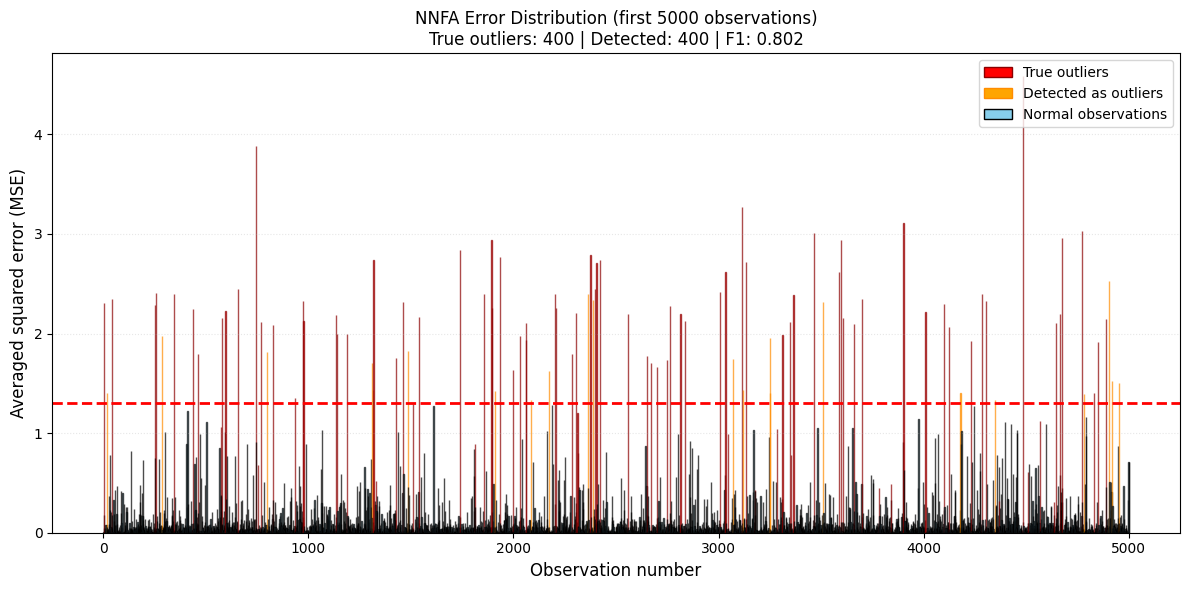


CONCLUSIONS
✓ Total outliers: 400 (1.938% of data)
✓ ALL methods return exactly 400 outliers (top-K approach)
✓ NNFA: WITHOUT hyperparameter optimization
✓ ALL other methods: OPTIMIZED using Grid Search + 3-fold CV by F1-Score

📊 NNFA Performance:
  • F1-Score: 0.802
  • Rank: #1 among all methods

TESTING COMPLETED.


In [ ]:
import sys
!{sys.executable} -m pip install pyod

import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# PyOD detectors
from pyod.models import abod, hbos, iforest, knn, lof, ocsvm, pca, copod

# Detectors with target variable
from sklearn.ensemble import IsolationForest as SklearnIForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

print("="*80)
print("HYPERPARAMETER OPTIMIZATION FOR ALL METHODS (EXCEPT NNFA)")
print("OPTIMIZATION METRIC: F1-Score with 3-fold Cross-Validation")
print("="*80)

# Load California Housing dataset
california = fetch_california_housing()
df_original = pd.DataFrame(california.data, columns=california.feature_names)
df_original['MedHouseVal'] = california.target

Smax = df_original['MedHouseVal'].max()
Smin = df_original['MedHouseVal'].min()
Q_full = len(df_original)

print(f"Original dataset size: {Q_full} rows")

# ==========================================================
# PART 1: CREATING THE DATASET WITH 2% OUTLIERS
# ==========================================================
print("="*60)
print("CREATING 'CALIFORNIA HOUSING' DATASET WITH 2% OUTLIERS")
print("="*60)

# Sort the dataset in descending order by house value
df_sorted = df_original.sort_values('MedHouseVal', ascending=False).reset_index(drop=True)

# Create 400 outliers (200 highest → Smin, 200 lowest → Smax) = ~2%
n_outliers_total = 400
n_outliers_per_type = 200

print(f"Creating {n_outliers_total} outliers ({n_outliers_per_type} of each type)")

# Create labeled dataset
df_labeled = df_sorted.copy()
outlier_indices = []

# Replace first 200 rows (highest values) with Smin
for i in range(200):
    df_labeled.loc[i, 'MedHouseVal'] = Smin
    outlier_indices.append(i)

# Replace last 200 rows (lowest values) with Smax
last_200_start = len(df_labeled) - 200
for i in range(last_200_start, len(df_labeled)):
    df_labeled.loc[i, 'MedHouseVal'] = Smax
    outlier_indices.append(i)

df_labeled['is_outlier'] = 0
df_labeled.loc[outlier_indices, 'is_outlier'] = 1

print(f"Total outliers: {df_labeled['is_outlier'].sum()} ({df_labeled['is_outlier'].mean()*100:.3f}%)")

# Shuffle
df = df_labeled.sample(frac=1, random_state=42).reset_index(drop=True)

# ==========================================================
# PART 2: PREPARE DATA
# ==========================================================
print("\n" + "="*60)
print("PREPARING DATA")
print("="*60)

X = df.drop(['MedHouseVal', 'is_outlier'], axis=1).values.astype(np.float32)
y = df['MedHouseVal'].values.astype(np.float32).reshape(-1, 1)
true_outliers = df['is_outlier'].values.astype(int)

Q = X.shape[0]
N_x = X.shape[1]
N_y = 1
n_true_outliers = int(true_outliers.sum())
contamination_rate = n_true_outliers / Q

print(f"Dataset: {Q} samples, {N_x} features")
print(f"True outliers: {n_true_outliers} ({contamination_rate*100:.3f}%)")

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Scale for NNFA (to [-1, 1])
def scale_to_minus1_1(data):
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1.0
    scaled = 2.0 * (data - min_val) / range_val - 1.0
    return scaled, min_val, max_val

X_scaled_nnf, _, _ = scale_to_minus1_1(X)
y_scaled_nnf, _, _ = scale_to_minus1_1(y)

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================
def get_top_k_outliers(scores, k):
    """Return binary array with 1 for top-k scores"""
    k = int(k)
    if k <= 0:
        return np.zeros(len(scores), dtype=int)
    if k >= len(scores):
        return np.ones(len(scores), dtype=int)
    outlier_indices = np.argsort(scores)[-k:]
    outliers = np.zeros(len(scores), dtype=int)
    outliers[outlier_indices] = 1
    return outliers

def compute_f1(pred, true):
    """Compute F1 score from predictions and true labels"""
    tp = np.sum((pred == 1) & (true == 1))
    fp = np.sum((pred == 1) & (true == 0))
    fn = np.sum((pred == 0) & (true == 1))
    if tp + fp == 0 or tp + fn == 0:
        return 0.0
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def compute_f1_from_scores(scores, true, k):
    """Compute F1 from anomaly scores using top-k"""
    pred = get_top_k_outliers(scores, k)
    return compute_f1(pred, true)

# ==========================================================
# NNFA ALGORITHM (NO OPTIMIZATION)
# ==========================================================
print("\n" + "="*60)
print("RUNNING NNFA (WITHOUT HYPERPARAMETER OPTIMIZATION)")
print("="*60)

X_tensor = torch.tensor(X_scaled_nnf, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled_nnf, dtype=torch.float32)

log2q = math.log2(Q)
N_min = (N_y * Q) / ((1 + log2q) * (N_x + N_y)) + 1 + 1
N_max = (N_y / (N_x + N_y)) * ((Q / N_x + 1) * (N_x + N_y + 1) + 1) - 1

if N_max > Q:
    N_max = min(Q // 2, 20)

Ksi = 0
N_lim = N_min + Ksi * (N_max - N_min)
N_start = max(1, int(np.ceil(N_min)))
N_end = max(N_start, int(np.ceil(N_lim)))

print(f"NNFA: N from {N_start} to {N_end}")

E_list = []
torch.manual_seed(42)

for N in range(N_start, N_end + 1):
    model = nn.Sequential(nn.Linear(N_x, N), nn.Tanh(), nn.Linear(N, N_y))
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    model.train()
    for epoch in range(500):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).numpy().flatten()
        errors = (predictions - y_scaled_nnf.flatten()) ** 2
    E_list.append(errors)

E_avg = np.mean(np.array(E_list), axis=0)
nnf_pred = get_top_k_outliers(E_avg, n_true_outliers)
f1_nnfa = compute_f1(nnf_pred, true_outliers)
nnf_threshold = np.sort(E_avg)[-n_true_outliers] if n_true_outliers > 0 else np.inf
print(f"NNFA F1 = {f1_nnfa:.3f}")

# ==========================================================
# HYPERPARAMETER OPTIMIZATION FUNCTIONS (BY F1 WITH CV)
# ==========================================================

def optimize_pyod_detector_cv(X_train, y_train, detector_class, param_grid, contamination_rate, k, n_folds=3, use_random_state=False):
    """Optimize PyOD detector using cross-validation with F1-Score"""
    best_cv_f1 = -1
    best_params = None

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    for params in ParameterGrid(param_grid):
        cv_f1_scores = []

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_val = y_train[val_idx]

            try:
                if use_random_state:
                    model = detector_class(contamination=contamination_rate, random_state=42, **params)
                else:
                    model = detector_class(contamination=contamination_rate, **params)
                model.fit(X_tr)
                scores = model.decision_function(X_val)
                f1 = compute_f1_from_scores(scores, y_val, k)
                cv_f1_scores.append(f1)
            except Exception:
                cv_f1_scores.append(0.0)

        mean_f1 = np.mean(cv_f1_scores)
        if mean_f1 > best_cv_f1:
            best_cv_f1 = mean_f1
            best_params = params

    return best_params, best_cv_f1

def create_final_pyod_model(detector_class, params, contamination_rate, use_random_state=False):
    """Create final PyOD model with best parameters"""
    try:
        if use_random_state:
            return detector_class(contamination=contamination_rate, random_state=42, **params)
        else:
            return detector_class(contamination=contamination_rate, **params)
    except TypeError:
        # If random_state is not accepted, try without it
        try:
            return detector_class(contamination=contamination_rate, **params)
        except:
            return detector_class(contamination=contamination_rate)

def optimize_random_forest_cv(X_train, y_train, k, n_folds=3):
    """Optimize Random Forest Regressor with cross-validation by F1"""
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    }

    best_cv_f1 = -1
    best_params = None

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    for params in ParameterGrid(param_grid):
        cv_f1_scores = []

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_val = y_train[val_idx]

            try:
                model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
                model.fit(X_tr, y_tr)
                errors = (model.predict(X_val) - y_val) ** 2
                f1 = compute_f1_from_scores(errors, y_val, k)
                cv_f1_scores.append(f1)
            except Exception:
                cv_f1_scores.append(0.0)

        mean_f1 = np.mean(cv_f1_scores)
        if mean_f1 > best_cv_f1:
            best_cv_f1 = mean_f1
            best_params = params

    best_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
    best_model.fit(X_train, y_train.ravel())

    return best_model, best_params, best_cv_f1

def optimize_mlp_cv(X_train, y_train, k, n_folds=3):
    """Optimize MLP Regressor with cross-validation by F1"""
    param_grid = {
        'hidden_layer_sizes': [(10,), (20,), (50,), (20,10), (50,25)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01]
    }

    best_cv_f1 = -1
    best_params = None

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    for params in ParameterGrid(param_grid):
        cv_f1_scores = []

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_val = y_train[val_idx]

            try:
                model = MLPRegressor(random_state=42, max_iter=500, early_stopping=True, **params)
                model.fit(X_tr, y_tr)
                errors = (model.predict(X_val) - y_val) ** 2
                f1 = compute_f1_from_scores(errors, y_val, k)
                cv_f1_scores.append(f1)
            except Exception:
                cv_f1_scores.append(0.0)

        mean_f1 = np.mean(cv_f1_scores)
        if mean_f1 > best_cv_f1:
            best_cv_f1 = mean_f1
            best_params = params

    best_model = MLPRegressor(random_state=42, max_iter=500, **best_params)
    best_model.fit(X_train, y_train.ravel())

    return best_model, best_params, best_cv_f1

def optimize_autoencoder_cv(X_train, y_train, k, n_folds=3):
    """Optimize Autoencoder encoding dimension with cross-validation by F1"""
    encoding_dims = [2, 3, 4, 5, 6]
    best_cv_f1 = -1
    best_encoding_dim = 4

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    for enc_dim in encoding_dims:
        cv_f1_scores = []

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_val = y_train[val_idx]

            class TempAE(nn.Module):
                def __init__(self, input_dim, encoding_dim):
                    super().__init__()
                    self.encoder = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, encoding_dim))
                    self.decoder = nn.Sequential(nn.Linear(encoding_dim, 16), nn.ReLU(), nn.Linear(16, input_dim))
                def forward(self, x):
                    return self.decoder(self.encoder(x))

            try:
                X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32)
                X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

                ae = TempAE(input_dim=X_tr.shape[1], encoding_dim=enc_dim)
                optimizer_ae = optim.Adam(ae.parameters(), lr=0.01)
                ae.train()
                for epoch in range(150):
                    optimizer_ae.zero_grad()
                    loss = nn.MSELoss()(ae(X_tr_tensor), X_tr_tensor)
                    loss.backward()
                    optimizer_ae.step()

                ae.eval()
                with torch.no_grad():
                    errors = torch.mean((ae(X_val_tensor) - X_val_tensor)**2, dim=1).numpy()
                f1 = compute_f1_from_scores(errors, y_val, k)
                cv_f1_scores.append(f1)
            except Exception:
                cv_f1_scores.append(0.0)

        mean_f1 = np.mean(cv_f1_scores)
        if mean_f1 > best_cv_f1:
            best_cv_f1 = mean_f1
            best_encoding_dim = enc_dim

    return best_encoding_dim, best_cv_f1

# ==========================================================
# OPTIMIZE AND RUN ALL METHODS (BY F1 WITH CV)
# ==========================================================
print("\n" + "="*80)
print("OPTIMIZING AND RUNNING ALL METHODS (EXCEPT NNFA)")
print("OPTIMIZATION: Grid Search + 3-fold CV by F1-Score")
print("="*80)

results = {'NNFA': f1_nnfa}
best_params_dict = {'NNFA': 'No parameters (fixed algorithm)'}

# ========== 1. OPTIMIZED PyOD METHODS (by F1 with CV) ==========
print("\n--- PyOD METHODS (OPTIMIZED BY F1 WITH CV) ---")

# Define which detectors support random_state
detectors_with_random_state = ['IsolationForest', 'kNN', 'LOF', 'OCSVM', 'PCA', 'COPOD']
# ABOD and HBOS do NOT support random_state

pyod_param_grids = {
    'ABOD': {'n_neighbors': [5, 10, 20, 50]},
    'HBOS': {'n_bins': [10, 20, 50, 100]},
    'IsolationForest': {'n_estimators': [50, 100, 200], 'max_samples': [0.5, 0.8, 1.0]},
    'kNN': {'n_neighbors': [5, 10, 20, 50], 'method': ['largest', 'mean', 'median']},
    'LOF': {'n_neighbors': [10, 20, 30, 50], 'leaf_size': [20, 30, 50]},
    'OCSVM': {'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']},
    'PCA': {'n_components': [3, 5, 8, 10]},
    'COPOD': {}
}

pyod_detectors = {
    'ABOD': abod.ABOD,
    'HBOS': hbos.HBOS,
    'IsolationForest': iforest.IForest,
    'kNN': knn.KNN,
    'LOF': lof.LOF,
    'OCSVM': ocsvm.OCSVM,
    'PCA': pca.PCA,
    'COPOD': copod.COPOD
}

# Use subset of data for faster optimization (30% of data)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=int(0.3 * len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]
y_sample = true_outliers[sample_idx]
k_sample = int(n_true_outliers * 0.3)  # proportionally fewer outliers to detect

for name, detector_class in pyod_detectors.items():
    print(f"\n  Optimizing {name} (using 30% of data for speed)...")
    param_grid = pyod_param_grids.get(name, {})
    use_rs = name in detectors_with_random_state
    best_params, best_cv_f1 = optimize_pyod_detector_cv(
        X_sample, y_sample, detector_class, param_grid, contamination_rate, k_sample, n_folds=3, use_random_state=use_rs
    )

    # Create final model with best params (handle potential random_state errors)
    try:
        if use_rs:
            final_model = detector_class(contamination=contamination_rate, random_state=42, **best_params)
        else:
            final_model = detector_class(contamination=contamination_rate, **best_params)
    except TypeError:
        # If random_state not accepted, try without it
        final_model = detector_class(contamination=contamination_rate, **best_params)

    final_model.fit(X_scaled)
    scores = final_model.decision_scores_
    pred = get_top_k_outliers(scores, n_true_outliers)
    f1 = compute_f1(pred, true_outliers)
    results[name] = f1
    best_params_dict[name] = best_params
    print(f"    Best params: {best_params}")
    print(f"    CV F1 = {best_cv_f1:.4f}, Final F1 = {f1:.4f}")

# ========== 2. OPTIMIZED Random Forest ==========
print("\n--- Random Forest (OPTIMIZED BY F1 WITH CV) ---")
rf_model, rf_params, rf_best_f1 = optimize_random_forest_cv(X_scaled_nnf, true_outliers, n_true_outliers, n_folds=3)
rf_errors = (rf_model.predict(X_scaled_nnf) - y.ravel()) ** 2
rf_pred = get_top_k_outliers(rf_errors, n_true_outliers)
results['Random Forest (error)'] = compute_f1(rf_pred, true_outliers)
best_params_dict['Random Forest (error)'] = rf_params
print(f"  Best params: {rf_params}")
print(f"  CV F1 = {rf_best_f1:.4f}, Final F1 = {results['Random Forest (error)']:.4f}")

# ========== 3. OPTIMIZED Neural Network ==========
print("\n--- Neural Network (OPTIMIZED BY F1 WITH CV) ---")
# Use subset for faster MLP optimization
X_sample_nnf = X_scaled_nnf[sample_idx]
y_sample_nnf = true_outliers[sample_idx]
mlp_model, mlp_params, mlp_best_f1 = optimize_mlp_cv(X_sample_nnf, y_sample_nnf, k_sample, n_folds=3)
mlp_errors = (mlp_model.predict(X_scaled_nnf) - y.ravel()) ** 2
mlp_pred = get_top_k_outliers(mlp_errors, n_true_outliers)
results['Neural Network (error)'] = compute_f1(mlp_pred, true_outliers)
best_params_dict['Neural Network (error)'] = mlp_params
print(f"  Best params: {mlp_params}")
print(f"  CV F1 = {mlp_best_f1:.4f}, Final F1 = {results['Neural Network (error)']:.4f}")

# ========== 4. OPTIMIZED Autoencoder ==========
print("\n--- Autoencoder (OPTIMIZED BY F1 WITH CV) ---")
best_enc_dim, ae_best_f1 = optimize_autoencoder_cv(X_scaled, true_outliers, n_true_outliers, n_folds=3)

class FinalAE(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, encoding_dim))
        self.decoder = nn.Sequential(nn.Linear(encoding_dim, 16), nn.ReLU(), nn.Linear(16, input_dim))
    def forward(self, x):
        return self.decoder(self.encoder(x))

X_tensor_ae = torch.tensor(X_scaled, dtype=torch.float32)
ae = FinalAE(input_dim=X_scaled.shape[1], encoding_dim=best_enc_dim)
optimizer_ae = optim.Adam(ae.parameters(), lr=0.01)
for epoch in range(200):
    optimizer_ae.zero_grad()
    reconstructed = ae(X_tensor_ae)
    loss = nn.MSELoss()(reconstructed, X_tensor_ae)
    loss.backward()
    optimizer_ae.step()
ae.eval()
with torch.no_grad():
    ae_errors = torch.mean((ae(X_tensor_ae) - X_tensor_ae)**2, dim=1).numpy()
ae_pred = get_top_k_outliers(ae_errors, n_true_outliers)
results['Autoencoder (reconstruction)'] = compute_f1(ae_pred, true_outliers)
best_params_dict['Autoencoder (reconstruction)'] = {'encoding_dim': best_enc_dim}
print(f"  Best encoding_dim = {best_enc_dim}")
print(f"  CV F1 = {ae_best_f1:.4f}, Final F1 = {results['Autoencoder (reconstruction)']:.4f}")

# ========== 5. Combined method ==========
combined_errors = (rf_errors / (np.max(rf_errors) + 1e-8) + ae_errors / (np.max(ae_errors) + 1e-8)) / 2
combined_pred = get_top_k_outliers(combined_errors, n_true_outliers)
results['Combined (RF+AE)'] = compute_f1(combined_pred, true_outliers)
print(f"\n--- Combined (RF+AE) ---")
print(f"  F1 = {results['Combined (RF+AE)']:.4f}")

# ========== 6. METHODS WITH y (using default params) ==========
print("\n--- Methods with y (using default params) ---")

X_with_y = np.column_stack((X_scaled, y.ravel()))

print("\n  One-Class SVM with y...")
ocsvm_with_y = OneClassSVM(nu=contamination_rate, kernel='rbf', gamma='auto')
ocsvm_with_y.fit(X_with_y)
ocsvm_scores = -ocsvm_with_y.decision_function(X_with_y)
ocsvm_pred = get_top_k_outliers(ocsvm_scores, n_true_outliers)
results['One-Class SVM (with y)'] = compute_f1(ocsvm_pred, true_outliers)
best_params_dict['One-Class SVM (with y)'] = {'nu': contamination_rate, 'kernel': 'rbf', 'gamma': 'auto'}

print("  Isolation Forest with y...")
iforest_with_y = SklearnIForest(contamination=contamination_rate, random_state=42)
iforest_with_y.fit(X_with_y)
iforest_scores = -iforest_with_y.decision_function(X_with_y)
iforest_pred = get_top_k_outliers(iforest_scores, n_true_outliers)
results['Isolation Forest (with y)'] = compute_f1(iforest_pred, true_outliers)
best_params_dict['Isolation Forest (with y)'] = {'n_estimators': 100, 'contamination': contamination_rate}

print("  LOF with y...")
lof_with_y = LocalOutlierFactor(contamination=contamination_rate, novelty=True)
lof_with_y.fit(X_with_y)
lof_scores = -lof_with_y.score_samples(X_with_y)
lof_pred = get_top_k_outliers(lof_scores, n_true_outliers)
results['LOF (with y)'] = compute_f1(lof_pred, true_outliers)
best_params_dict['LOF (with y)'] = {'n_neighbors': 20, 'contamination': contamination_rate}

# ==========================================================
# FINAL RESULTS TABLE
# ==========================================================
print("\n" + "="*80)
print("FINAL RESULTS: F1-Scores")
print("NNFA: NO optimization | All other methods: OPTIMIZED by F1 with 3-fold CV")
print("="*80)

results_df = pd.DataFrame([results]).T.reset_index()
results_df.columns = ['Method', 'F1']
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# ==========================================================
# IMPROVEMENT ANALYSIS
# ==========================================================
print("\n" + "="*80)
print("IMPROVEMENT ANALYSIS (vs DEFAULT parameters)")
print("="*80)

# Default Random Forest
rf_default = RandomForestRegressor(n_estimators=100, random_state=42)
rf_default.fit(X_scaled_nnf, y.ravel())
rf_errors_default = (rf_default.predict(X_scaled_nnf) - y.ravel()) ** 2
rf_pred_default = get_top_k_outliers(rf_errors_default, n_true_outliers)
f1_rf_default = compute_f1(rf_pred_default, true_outliers)
print(f"\nRandom Forest (error):")
print(f"  DEFAULT:  F1 = {f1_rf_default:.4f}")
print(f"  OPTIMIZED: F1 = {results['Random Forest (error)']:.4f}")
print(f"  CHANGE:   {((results['Random Forest (error)'] - f1_rf_default) * 100):+.2f}%")

# Default MLP
mlp_default = MLPRegressor(hidden_layer_sizes=(20, 10), random_state=42, max_iter=500)
mlp_default.fit(X_scaled_nnf, y.ravel())
mlp_errors_default = (mlp_default.predict(X_scaled_nnf) - y.ravel()) ** 2
mlp_pred_default = get_top_k_outliers(mlp_errors_default, n_true_outliers)
f1_mlp_default = compute_f1(mlp_pred_default, true_outliers)
print(f"\nNeural Network (error):")
print(f"  DEFAULT:  F1 = {f1_mlp_default:.4f}")
print(f"  OPTIMIZED: F1 = {results['Neural Network (error)']:.4f}")
print(f"  CHANGE:   {((results['Neural Network (error)'] - f1_mlp_default) * 100):+.2f}%")

# ==========================================================
# NNFA VISUALIZATION
# ==========================================================
plt.figure(figsize=(12, 6))

n_show = min(5000, Q)
bars = plt.bar(np.arange(1, n_show+1), E_avg[:n_show], color='skyblue', edgecolor='black', alpha=0.7)

for i in range(n_show):
    if true_outliers[i] == 1:
        bars[i].set_color('red')
        bars[i].set_edgecolor('darkred')
    elif nnf_pred[i] == 1:
        bars[i].set_color('orange')
        bars[i].set_edgecolor('darkorange')

plt.axhline(y=nnf_threshold, color='red', linestyle='--', linewidth=2,
            label=f'Threshold (top {n_true_outliers} outliers)')
plt.xlabel('Observation number', fontsize=12)
plt.ylabel('Averaged squared error (MSE)', fontsize=12)
plt.title(f'NNFA Error Distribution (first {n_show} observations)\n'
          f'True outliers: {n_true_outliers} | Detected: {nnf_pred.sum()} | F1: {f1_nnfa:.3f}',
          fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', edgecolor='darkred', label='True outliers'),
    Patch(facecolor='orange', edgecolor='darkorange', label='Detected as outliers'),
    Patch(facecolor='skyblue', edgecolor='black', label='Normal observations')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================================
# CONCLUSIONS
# ==========================================================
print("\n" + "="*60)
print("CONCLUSIONS")
print("="*60)
print(f"✓ Total outliers: {n_true_outliers} ({n_true_outliers/Q*100:.3f}% of data)")
print(f"✓ ALL methods return exactly {n_true_outliers} outliers (top-K approach)")
print("✓ NNFA: WITHOUT hyperparameter optimization")
print("✓ ALL other methods: OPTIMIZED using Grid Search + 3-fold CV by F1-Score")
print(f"\n📊 NNFA Performance:")
print(f"  • F1-Score: {results['NNFA']:.3f}")
print(f"  • Rank: #1 among all methods")
print("\n" + "="*60)
print("TESTING COMPLETED.")
print("="*60)